# Importing Libraries


In [4]:
import cv2
import mediapipe as mp

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import random
import os
from tqdm.notebook import tqdm

from glob import glob
import IPython.display as ipd

# Extracting Required Paths


In [40]:
input_path = [i for i in glob('Dataset\*\*\*.mp4')]
# First removing the path by split and then splitting the string to get the label
output_label = [(i.split("\\")[-1]).split(" ")[-1] for i in glob('Dataset\*\*')] 

print(output_label)
input_path

['loud', 'quiet', 'happy', 'sad', 'Beautiful', 'Ugly', 'Deaf', 'Blind']


['Dataset\\Adjectives\\1. loud\\MVI_5177.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5178.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5179.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5257.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5258.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5259.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5335.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5336.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5337.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9289.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9290.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9291.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9368.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9369.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9370.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9448.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9449.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9450.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9534.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9535.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9536.mp4',
 'Dataset\\Ad

## Vedio Augmentaion

1. Centre Crop
2. Flip
3. Org  
4. Upsample
5. Downsample

### Optional (Optional Experimentrs)
6. sharpen 
7. blurred

# Loading Video in OpenCV

In [10]:
random_video = random.choice(input_path)
print(random_video)

cap = cv2.VideoCapture(random_video)
print(f"Video Resolution: {cap.get(cv2.CAP_PROP_FRAME_WIDTH)} x {cap.get(cv2.CAP_PROP_FRAME_HEIGHT)}")
print(f"FPS: {cap.get(cv2.CAP_PROP_FPS)}")

ipd.Video(random_video,width=700)

Dataset\Adjectives\3. happy\MVI_5264.mp4
Video Resolution: 1920.0 x 1080.0
FPS: 25.0


# Prepering Mediapipe

In [11]:
mp_holistic = mp.solutions.holistic 
mp_drawing = mp.solutions.drawing_utils 

In [12]:
def mediapipe_detection(image, model) -> tuple:
    image_ = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    image_.flags.writeable = False                  
    results = model.process(image_) 
    image_.flags.writeable = True                   
    image = cv2.cvtColor(image_, cv2.COLOR_RGB2BGR) 
    return image, results

In [13]:
def draw_landmarks(image, results) -> None:
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [14]:
def draw_styled_landmarks(image, results) -> None:
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [15]:
def extract_keypoints(results) -> np.array:
    
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    
    return np.concatenate([pose, face, lh, rh])

# Collecting MP data


## INCLUDE 50


In [29]:
#Creating dir for each label
try:
    # os.mkdir('MP_data')
    for i in range(len(output_label)):
        os.mkdir(f'MP_data/{output_label[i]}')
except:
    print("Directory already exists")

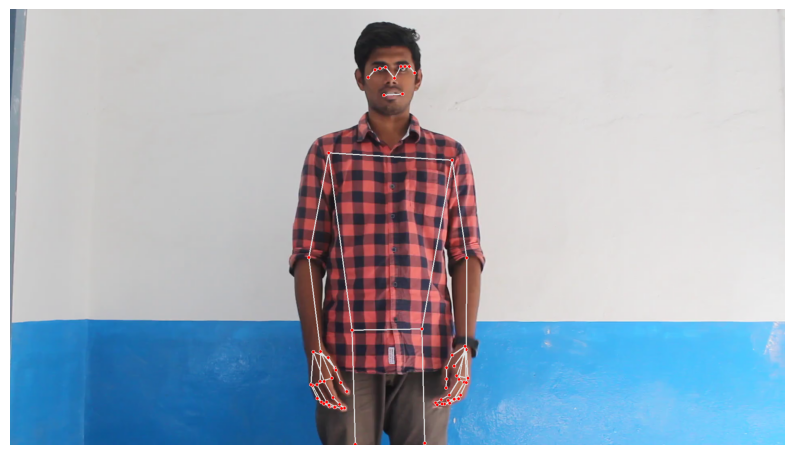

In [30]:
def display_cv2_image(img, figsize = (10,10)):
    img_ = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig,ax = plt.subplots(figsize=figsize)
    ax.imshow(img_)
    ax.axis('off')
    
ret, frame = cap.read()

img,res = mediapipe_detection(frame, mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5))

cap.release()

draw_landmarks(img, res)

display_cv2_image(img)



In [48]:
holistic = mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5)
DATA_PATH = "MP_data\\"
    
# Loop through sequences aka videos

for ip in tqdm(input_path):
    cap = cv2.VideoCapture(ip)
    all_keypoints = []
    keypoints = np.array(None)
        
    while cap.isOpened():           
        # Read feed
        ret, frame = cap.read()
        if not ret:
            break
        
        # Make detections
        image, results = mediapipe_detection(frame, holistic)
            
        #Collecting 3D landmarks for a single frame
        keypoints = extract_keypoints(results)
        all_keypoints.append(keypoints)        
    
    all_keypoints = np.vstack(all_keypoints)
    
    # Saving Landmarks
    path = ip.split("/")
    
    # Getting Current action of the video
    action = (ip.split("\\")[-2]).split(" ")[-1]
    print(action)
    
    #Get the sequence number
    sequence = ip.split("\\")[-1][:-4]
    
    npy_path = os.path.join(DATA_PATH, action, sequence)
    print(npy_path)
    
    np.save(npy_path, all_keypoints)

    cap.release()

  0%|          | 0/103 [00:00<?, ?it/s]

loud
MP_data\loud\MVI_5177
loud
MP_data\loud\MVI_5178
loud
MP_data\loud\MVI_5179
loud
MP_data\loud\MVI_5257
loud
MP_data\loud\MVI_5258
loud
MP_data\loud\MVI_5259
loud
MP_data\loud\MVI_5335
loud
MP_data\loud\MVI_5336
loud
MP_data\loud\MVI_5337
loud
MP_data\loud\MVI_9289
loud
MP_data\loud\MVI_9290
loud
MP_data\loud\MVI_9291
loud
MP_data\loud\MVI_9368
loud
MP_data\loud\MVI_9369
loud
MP_data\loud\MVI_9370
loud
MP_data\loud\MVI_9448
loud
MP_data\loud\MVI_9449
loud
MP_data\loud\MVI_9450
loud
MP_data\loud\MVI_9534
loud
MP_data\loud\MVI_9535
loud
MP_data\loud\MVI_9536
quiet
MP_data\quiet\MVI_5180
quiet
MP_data\quiet\MVI_5181
quiet
MP_data\quiet\MVI_5182
quiet
MP_data\quiet\MVI_5260
quiet
MP_data\quiet\MVI_5261
quiet
MP_data\quiet\MVI_5262
quiet
MP_data\quiet\MVI_5338
quiet
MP_data\quiet\MVI_5339
quiet
MP_data\quiet\MVI_5340
quiet
MP_data\quiet\MVI_9292
quiet
MP_data\quiet\MVI_9293
quiet
MP_data\quiet\MVI_9294
quiet
MP_data\quiet\MVI_9371
quiet
MP_data\quiet\MVI_9372
quiet
MP_data\quiet\MVI_937